In [5]:
!pip install modeller

In [6]:
import os
os.environ["KEY_MODELLER"] = "MODELIRANJE"

In [8]:
from modeller import environ, selection, log
from modeller.scripts import complete_pdb

def dope_score(pdbfile):
    """Calculate total and per-residue DOPE score for a given PDB file."""
    log.none()  # suppress Modeller output for cleanliness
    env = environ()
    env.libs.topology.read(file='$(LIB)/top_heav.lib')
    env.libs.parameters.read(file='$(LIB)/par.lib')

    mdl = complete_pdb(env, pdbfile)
    atmsel = selection(mdl)
    score = atmsel.assess_dope()
    nres = len(mdl.residues)
    return score, score / nres

In [9]:
for pdb in [ "model_02.pdb"]:
    total, per_res = dope_score(pdb)
    print(f"{pdb}\tDOPE_total = {total:.1f}\tDOPE_per_res = {per_res:.3f}")


>> Model assessment by DOPE potential
DOPE score               : -85806.585938
model_02.pdb	DOPE_total = -85806.6	DOPE_per_res = -105.155


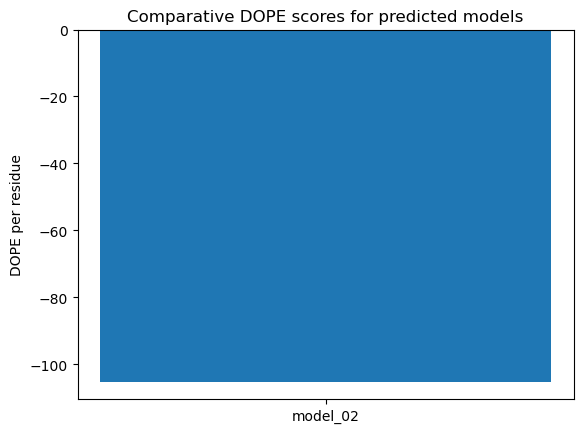

In [11]:
import matplotlib.pyplot as plt

models = [ "model_02"]
dope_vals = [-105.155]  # Replace with your own per_res values

plt.bar(models, dope_vals)
plt.ylabel("DOPE per residue")
plt.title("Comparative DOPE scores for predicted models")
plt.show()
